In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import matplotlib.pyplot as plt
import time
from scipy.optimize import fmin_l_bfgs_b

In [ ]:
# Global constants
CONTENT_WEIGHT = 1
STYLE_WEIGHT = 1e6
TOTAL_VARIATION_WEIGHT = 1e-4
MAX_DIM = 256  # Reduced image size to avoid memory issues
ITERATIONS = 1000

# Define content and style layers according to the paper
CONTENT_LAYERS = ['block4_conv2']
STYLE_LAYERS = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

In [ ]:
def load_and_process_image(path, max_dim=MAX_DIM):
    """Load and preprocess an image for VGG19 with smaller dimensions."""
    img = load_img(path)

    # Resize image while preserving aspect ratio
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = tuple([int(dim * scale) for dim in img.size])
    img = img.resize(new_size)

    # Convert to array and add batch dimension
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for VGG19
    img_array = preprocess_input(img_array)

    return img_array

In [ ]:
def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    x = processed_img.copy()

    # Remove batch dimension
    if len(x.shape) == 4:
        x = np.squeeze(x, axis=0)

    # Undo VGG preprocessing
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]  # Convert BGR to RGB

    # Clip to valid range
    x = np.clip(x, 0, 255).astype('uint8')

    return x

In [ ]:
def get_model():
    """Create a model that outputs the intermediate layers."""
    # Load VGG19
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    # replace max pooling with average pooling
    output_dict = {}
    input_layer, *layers = vgg.layers
    x = input_layer.output
    output_dict[input_layer.name] = x

    for layer in layers:
        if isinstance(layer, keras.layers.MaxPooling2D):
            layer = keras.layers.AveragePooling2D(
                pool_size=layer.pool_size,
                strides=layer.strides,
                padding=layer.padding,
                data_format=layer.data_format,
                name=f"{layer.name}_avg"
            )

        x=layer(x)
        output_dict[layer.name] = x

    # Get outputs of specific layers
    #outputs = {layer.name: layer.output for layer in vgg.layers
               #if layer.name in CONTENT_LAYERS + STYLE_LAYERS}

    # Create model
    return tf.keras.Model(inputs=vgg.input, outputs=output_dict)

In [ ]:
def gram_matrix(input_tensor):
    """Memory-efficient implementation of Gram matrix calculation."""
    # Ensure we're working with float32
    input_tensor = tf.cast(input_tensor, tf.float32)

    # Get dimensions
    shape = tf.shape(input_tensor)
    batch_size, height, width, num_filters = shape[0], shape[1], shape[2], shape[3]

    # Reshape the tensor: [batch_size, (height * width), num_filters]
    features = tf.reshape(input_tensor, (batch_size, height * width, num_filters))

    # Calculate gram matrix with batched matmul for better memory efficiency
    # Normalize by dividing by the number of locations (height * width)
    # G = (1/N) * F * F^T
    gram = tf.matmul(features, features, transpose_a=True)
    gram = gram / tf.cast(height * width, tf.float32)

    return gram

In [ ]:
@tf.function
def get_content_loss(base_content, target_content):
    """Compute content loss."""
    return tf.reduce_mean(tf.square(base_content - target_content)) / 2

In [ ]:
@tf.function
def get_style_loss(base_style, target_style):
    """Compute style loss."""
    return tf.reduce_mean(tf.square(base_style - target_style))

In [ ]:
@tf.function
def get_total_variation_loss(img):
    """Compute total variation loss for smoothness."""
    x_deltas = img[:, :, 1:, :] - img[:, :, :-1, :]
    y_deltas = img[:, 1:, :, :] - img[:, :-1, :, :]
    return tf.reduce_sum(tf.abs(x_deltas)) + tf.reduce_sum(tf.abs(y_deltas))

In [ ]:
def get_feature_representations(model, content_path, style_path):
    """Extract content and style features."""
    content_image = load_and_process_image(content_path)
    style_image = load_and_process_image(style_path)

    # Get feature representations
    content_outputs = model(content_image)
    style_outputs = model(style_image)

    # Extract content and style features
    content_features = {layer_name: value
                       for layer_name, value in content_outputs.items()
                       if layer_name in CONTENT_LAYERS}

    # Pre-compute gram matrices for style layers to save memory
    style_features = {layer_name: gram_matrix(value)
                     for layer_name, value in style_outputs.items()
                     if layer_name in STYLE_LAYERS}

    return content_features, style_features


In [ ]:
# Custom TensorFlow function to compute loss
@tf.function
def compute_loss(model, image, content_features, style_features):
    """Compute the total loss."""
    with tf.GradientTape() as tape:
        tape.watch(image)

        # Get features of current image
        outputs = model(image)

        # Content loss
        content_loss = tf.add_n([
            get_content_loss(content_features[name], outputs[name])
            for name in CONTENT_LAYERS
        ])
        content_loss *= CONTENT_WEIGHT / len(CONTENT_LAYERS)

        # Style loss
        style_loss = tf.add_n([
            get_style_loss(style_features[name], gram_matrix(outputs[name]))
            for name in STYLE_LAYERS
        ])
        style_loss *= STYLE_WEIGHT / len(STYLE_LAYERS)

        # Total variation loss
        total_variation_loss = get_total_variation_loss(image) * TOTAL_VARIATION_WEIGHT

        # Total loss
        total_loss = content_loss + style_loss + total_variation_loss

    # Get gradients
    grads = tape.gradient(total_loss, image)

    return total_loss, grads

In [ ]:
class Evaluator:
    """Class for L-BFGS optimization."""
    def __init__(self, model, content_features, style_features, img_shape):
        self.model = model
        self.content_features = content_features
        self.style_features = style_features
        self.shape = img_shape

    def loss(self, x):
        """Calculate loss and gradient for L-BFGS."""
        img = x.reshape(self.shape)
        img = tf.convert_to_tensor(img, dtype=tf.float32)

        # Compute loss and gradients
        loss, grad = compute_loss(self.model, img, self.content_features, self.style_features)

        # Convert to numpy for L-BFGS
        loss_value = loss.numpy().astype(np.float64)
        grad_values = grad.numpy().flatten().astype(np.float64)

        return loss_value, grad_values

    def f(self, x):
        """Function value only for L-BFGS."""
        loss_value, _ = self.loss(x)
        return loss_value

    def g(self, x):
        """Gradient value only for L-BFGS."""
        _, grad_values = self.loss(x)
        return grad_values

In [ ]:
def run_style_transfer(content_path, style_path):
    """Run the style transfer algorithm."""
    print("Building model...")
    model = get_model()

    print("Loading images and extracting features...")
    content_features, style_features, content_image = get_feature_representations(
        model, content_path, style_path
    )

    # Initialize with the content image
    initial_image = content_image.astype(np.float64)
    img_shape = initial_image.shape
    initial_x = initial_image.flatten()

    # Create evaluator
    evaluator = Evaluator(model, content_features, style_features, img_shape)

    # Optimize with L-BFGS
    print(f"Starting optimization with L-BFGS for {ITERATIONS} iterations...")
    start_time = time.time()

    best_loss = float('inf')
    best_img = None

    # Main optimization loop
    for i in range(ITERATIONS):
        print(f"Iteration {i+1}/{ITERATIONS}")
        iteration_start = time.time()

        # Run L-BFGS optimization
        x, min_val, info = fmin_l_bfgs_b(
            evaluator.f,
            initial_x,
            fprime=evaluator.g,
            maxfun=20,  # Number of function evaluations per iteration
            maxiter=1   # Just one outer iteration at a time
        )

        print(f"Loss: {min_val}")
        print(f"Time for iteration {i+1}: {time.time() - iteration_start:.2f}s")

        # Track best result
        if min_val < best_loss:
            best_loss = min_val
            best_img = x.reshape(img_shape)

        # Update initial point for next iteration
        initial_x = x

    # Return the best result
    final_img = best_img if best_img is not None else x.reshape(img_shape)
    final_img = deprocess_image(final_img)

    print(f"Total time: {time.time() - start_time:.2f}s")

    return final_img

In [ ]:
content_path = "drive/MyDrive/Intro CV/Final Project/CV Final Project/code/dataset/paris.jpg"  # Replace with your content image path
style_path = "drive/MyDrive/Intro CV/Final Project/CV Final Project/code/dataset/starry_night.jpg"      # Replace with your style image path

In [ ]:
# Run style transfer
result_image = run_style_transfer(content_path, style_path)

Building model...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loading images and extracting features...
Starting optimization with L-BFGS for 1000 iterations...
Iteration 1/1000
Loss: 814626447032320.0
Time for iteration 1: 4.06s
Iteration 2/1000
Loss: 668890086506496.0
Time for iteration 2: 0.26s
Iteration 3/1000
Loss: 534807951966208.0
Time for iteration 3: 0.28s
Iteration 4/1000
Loss: 424250494156800.0
Time for iteration 4: 0.34s
Iteration 5/1000
Loss: 336115517095936.0
Time for iteration 5: 0.38s
Iteration 6/1000
Loss: 267439510126592.0
Time for iteration 6: 0.36s
Iteration 7/1000
Loss: 214828794773504.0
Time for iteration 7: 0.38s
Iteration 8/1000
Loss: 174356697186304.0
Time for iteration 8: 0.35s
Iteration 9/1000
Loss: 143252191707136.0
Time for iteration 9: 0.29s
Iteration 10/1000
Loss: 118890650664960.0
Time for iteration 10: 0.35s
Iteration 11/1000
Loss: 100031658983424.0
Time for iteration 11: 0.32s
Iteration 12/1000
Loss: 95627715280896.0
Time for iteration 12: 0.25s

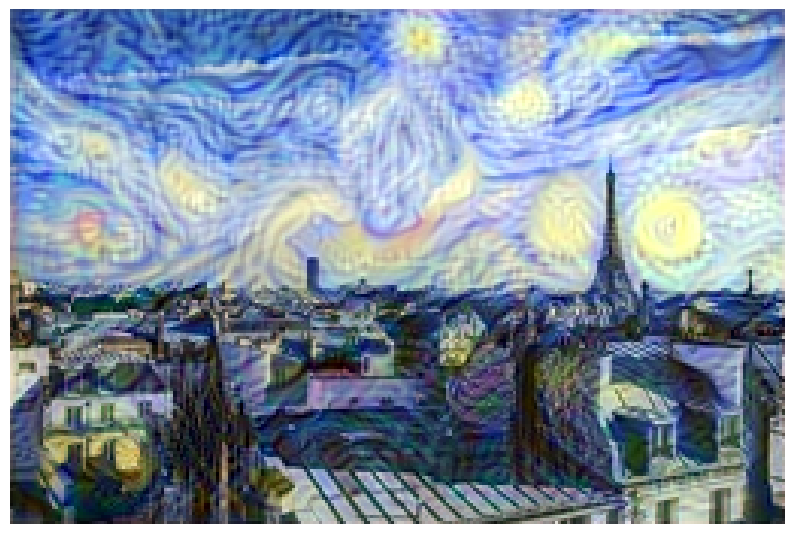

In [ ]:
# Display result - iteration=1000
plt.figure(figsize=(10, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()

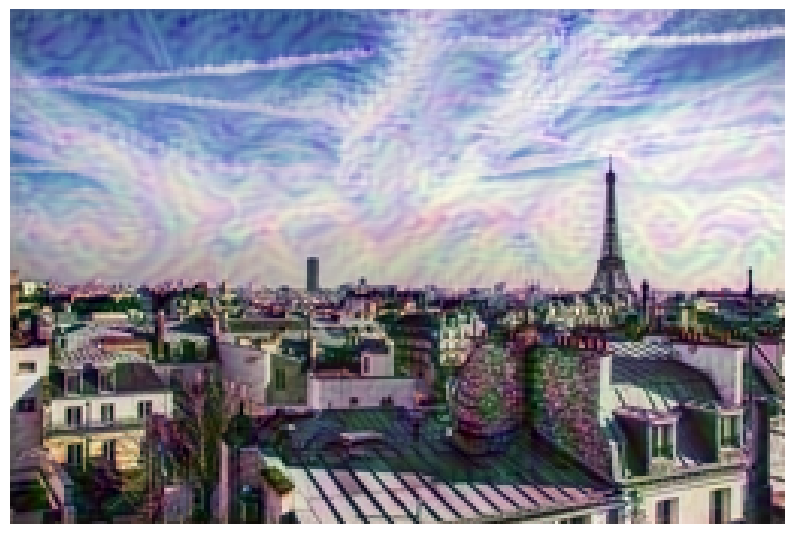

In [ ]:
# Display result - iteration=10
plt.figure(figsize=(10, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()

In [ ]:
# Save result
array_to_img(result_image).save("stylized_image3.jpg")
print("Style transfer complete! Image saved as 'stylized_image3.jpg'")

Style transfer complete! Image saved as 'stylized_image3.jpg'
